In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.preprocessing import RobustScaler,FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
import seaborn as sns
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from sklearn.decomposition import PCA

In [2]:
Data_path=r"C:\Users\mosa\Downloads\CVD_cleaned.csv"
df=pd.read_csv(Data_path)
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


In [3]:
class CustomNumericalImputer(BaseEstimator, TransformerMixin):
    def __init__(self,stratigy="median"):
        self.stratigy=stratigy

    def fit(self,x,y=None):
        x=np.asarray(x,dtype=float)

        if self.stratigy=="median":
            self.impute_=np.nanmedian(x,axis=0)
        elif self.stratigy=="mean":
            self.impute_=np.nanmean(x,axis=0)
        else:
            raise ValueError(
                "error choice between median,mean"
            )

        if np.isnan(self.impute_).any():
            raise ValueError("At least one column contains only NaN values.")

        return self

    def transform(self,x):
        x=np.asarray(x,dtype=float).copy()

        for i in range(x.shape[1]):
            mask=np.isnan(x[:,i])
            x[mask,i]=self.impute_[i]

        return x



In [4]:
def EDA(df):
    print("="*60)
    print("Shape")
    print("="*60)
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")


    print("\n" + "=" * 60)
    print("Head")
    print("="*60)
    print(df.head(7))

    print("\n" + "=" * 60)
    print("Info")
    print("="*60)
    df.info()

    print("\n" + "=" * 60)
    print("Dtype Of Data")
    print("="*60)
    print(df.dtypes)

    print("\n" + "=" * 60)
    print("Missing Value")
    print("="*60)
    missing=pd.DataFrame({
        "Missing":df.isnull().sum(),
        "Percentage":df.isnull().sum()*100
    })
    print(missing[missing["Missing"]>0])

    print("\n" + "=" * 60)
    print("Duplicated")
    print("="*60)
    print(f"{df[df.duplicated()]}")
    print(f"\n Duplicate In Data: {df.duplicated().sum()}")

    num_col=df.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_col=df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    print("\n" + "=" * 60)
    print("Numerical Columns")
    print("="*60)

    print(num_col)

    print("\n" + "=" * 60)
    print("Categorical Columns")
    print("="*60)

    print(cat_col)

    print("\n" + "=" * 60)
    print("Numerical Description")
    print("="*60)

    if len(num_col)>0:
        print(df[num_col].describe())

    print("\n" + "=" * 60)
    print("Categorical Description")
    print("="*60)

    if len(cat_col)>0:
        print(df[cat_col].describe())

    print("\n" + "=" * 60)
    print("Uniqe Value")
    print("="*60)

    uniqe=pd.DataFrame({
        "num_uniqe":df.nunique()
    })
    print(uniqe)

    print("\n" + "=" * 60)
    print("Value Count")
    print("="*60)

    for i in cat_col:
        print(f"----{i}----")
        print(df[i].value_counts(dropna=False))

    print("\n" + "=" * 60)
    print("13. SKEWNESS")
    print("=" * 60)

    if len(num_col) > 0:

        skewness = (df[num_col].skew().sort_values(ascending=False))

        print(skewness)



EDA(df)

Shape
Rows: 308854
Columns: 19

Head
  General_Health                  Checkup Exercise Heart_Disease Skin_Cancer  \
0           Poor  Within the past 2 years       No            No          No   
1      Very Good     Within the past year       No           Yes          No   
2      Very Good     Within the past year      Yes            No          No   
3           Poor     Within the past year      Yes           Yes          No   
4           Good     Within the past year       No            No          No   
5           Good     Within the past year       No            No          No   
6           Fair     Within the past year      Yes           Yes          No   

  Other_Cancer Depression Diabetes Arthritis     Sex Age_Category  \
0           No         No       No       Yes  Female        70-74   
1           No         No      Yes        No  Female        70-74   
2           No         No      Yes        No  Female        60-64   
3           No         No      Yes        No  

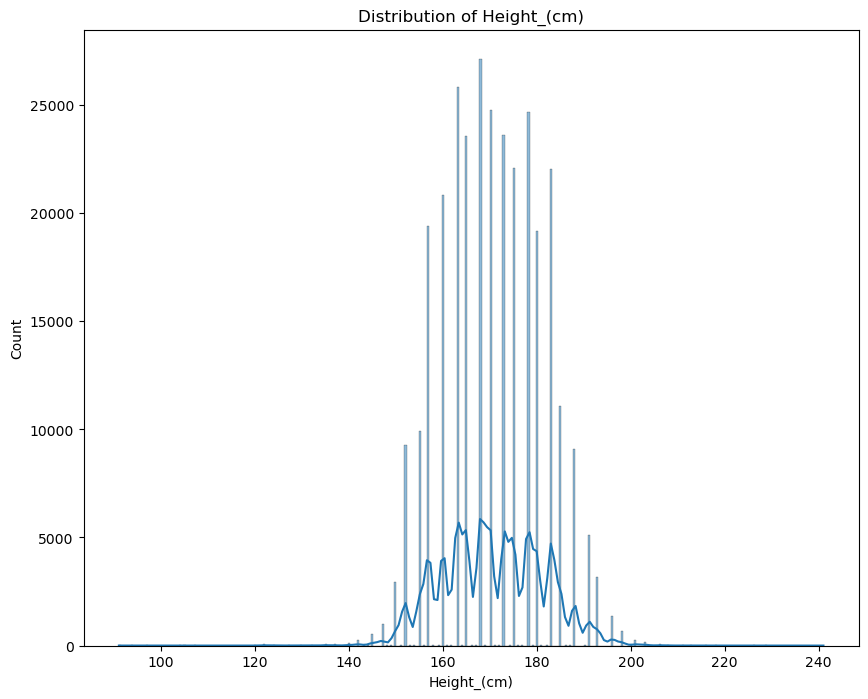

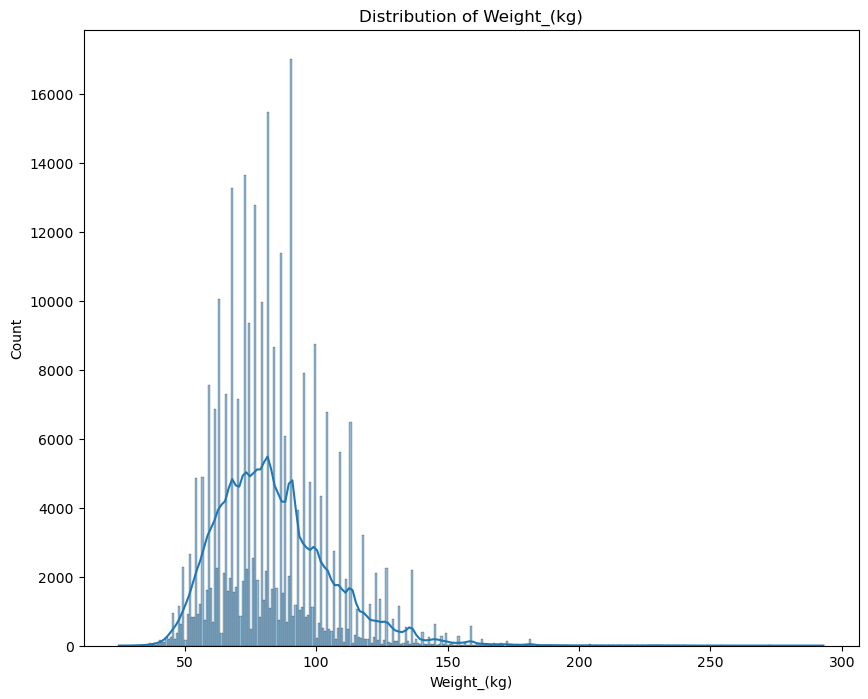

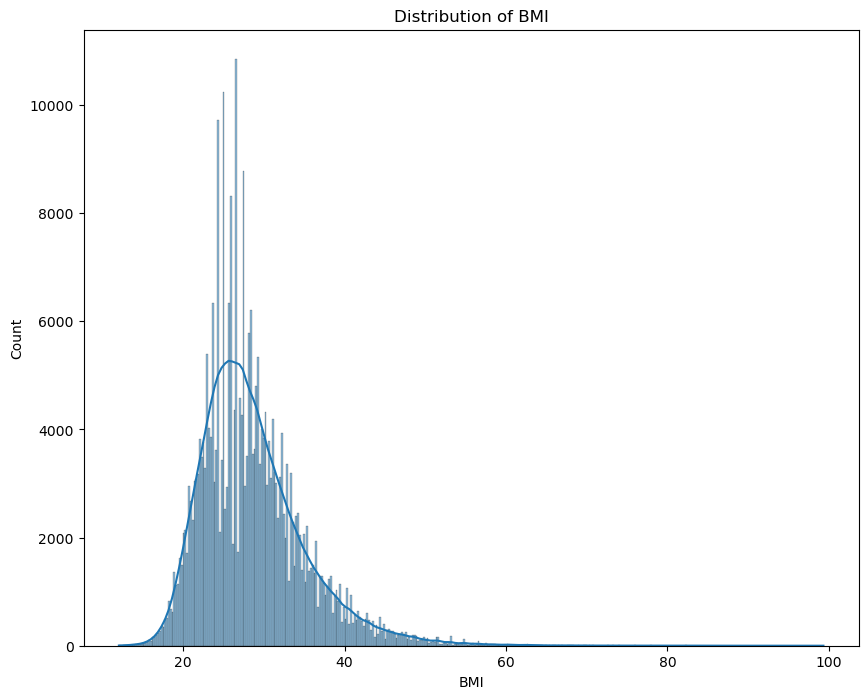

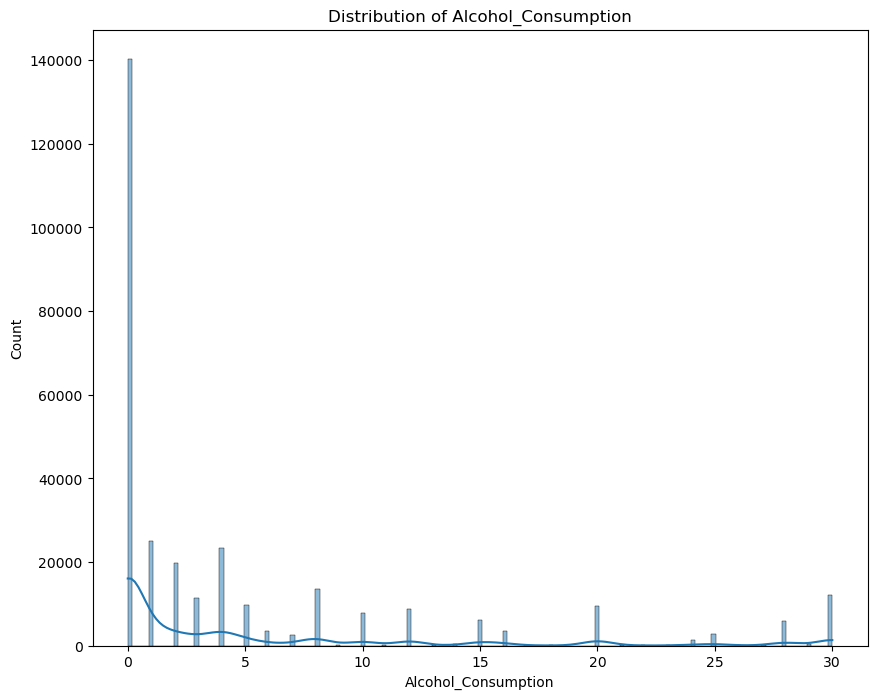

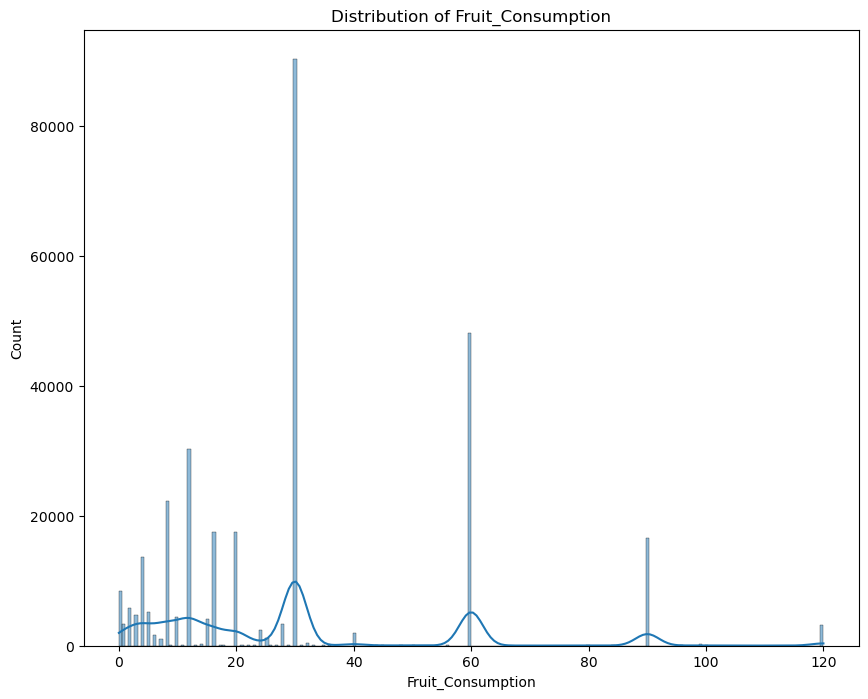

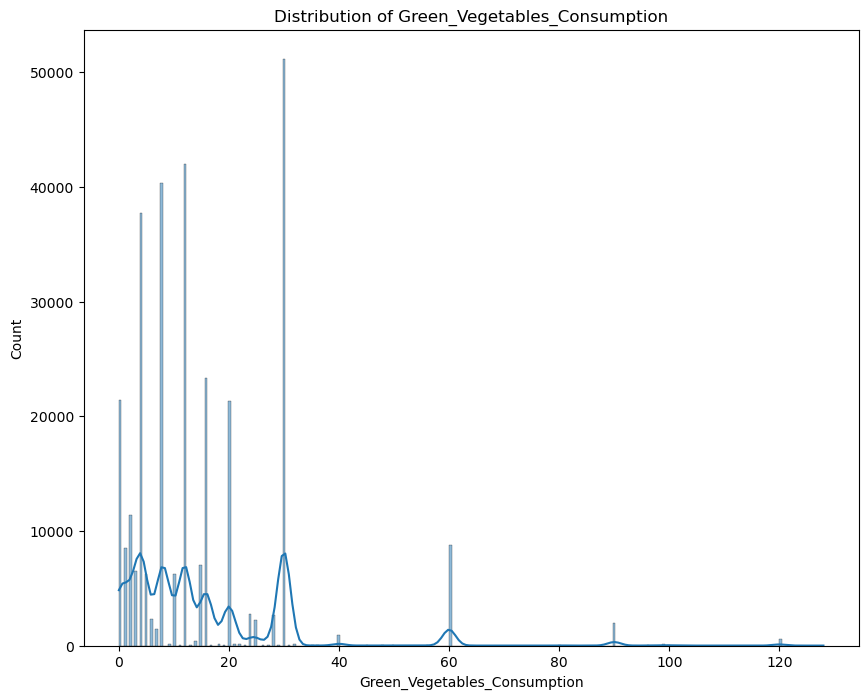

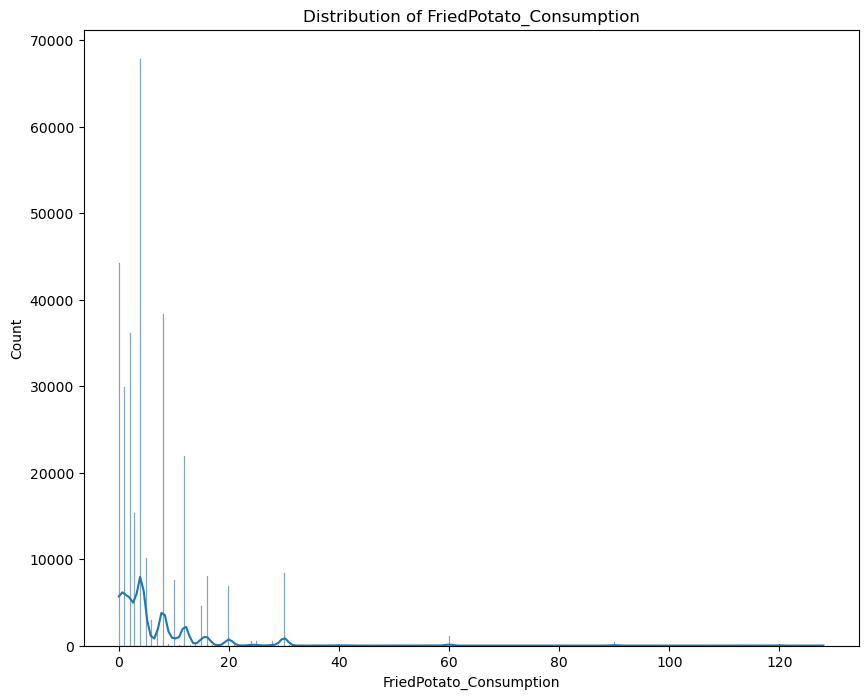

In [5]:
num_col=df.select_dtypes(include=["int64","float64"]).columns.tolist()
for i in num_col:
    plt.figure(figsize=(10,8))
    sns.histplot(data=df,x=i,kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()

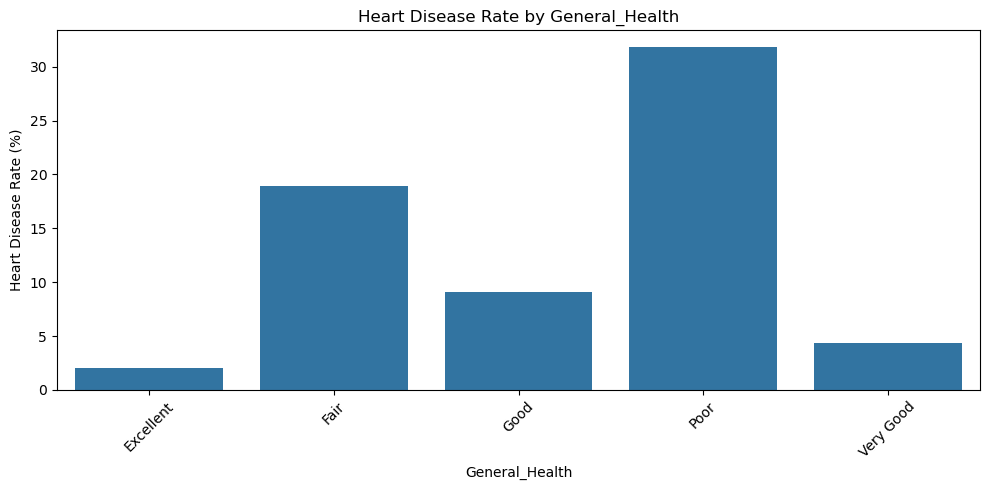

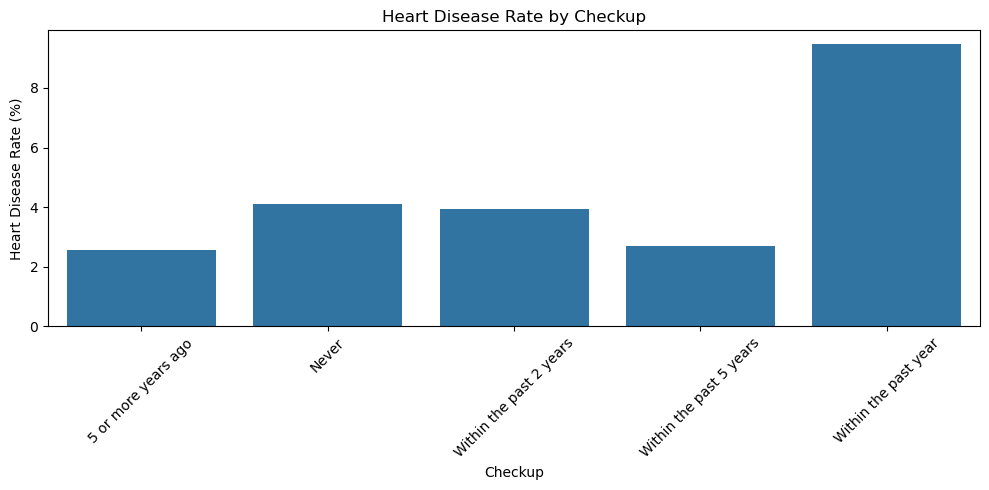

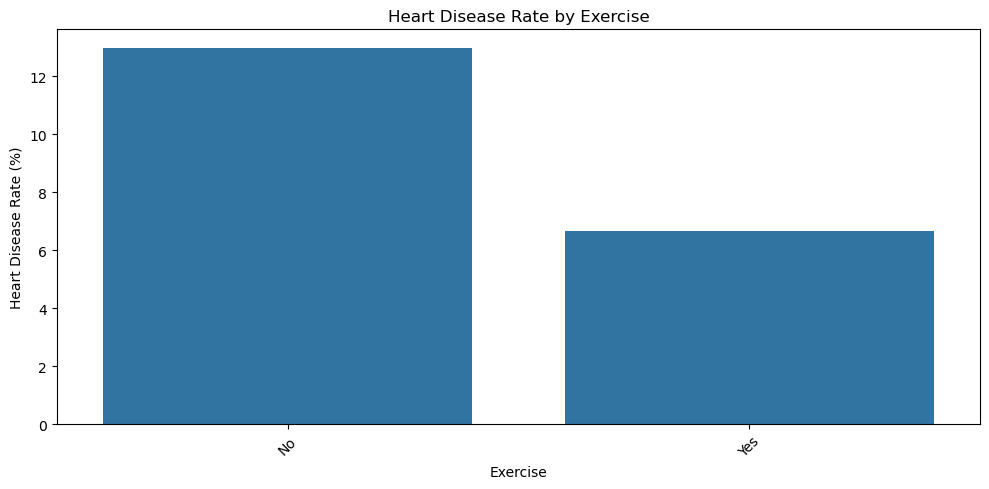

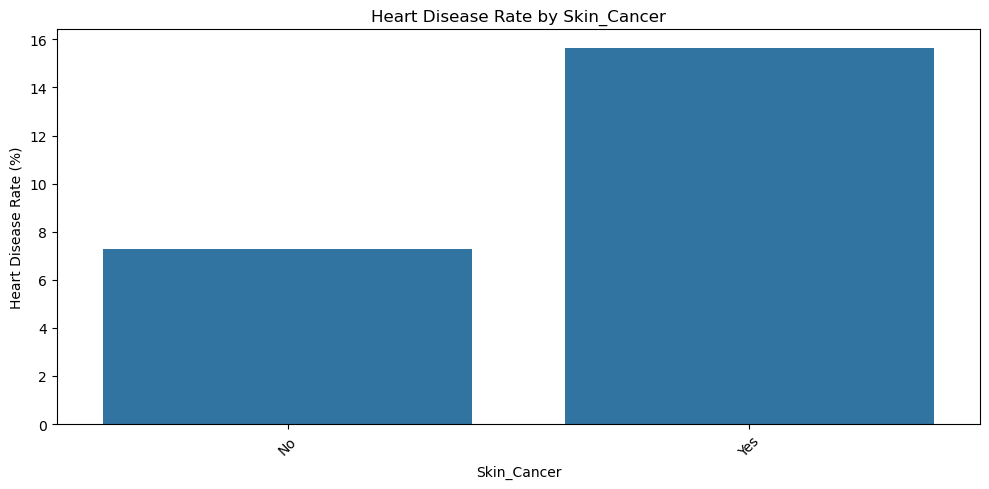

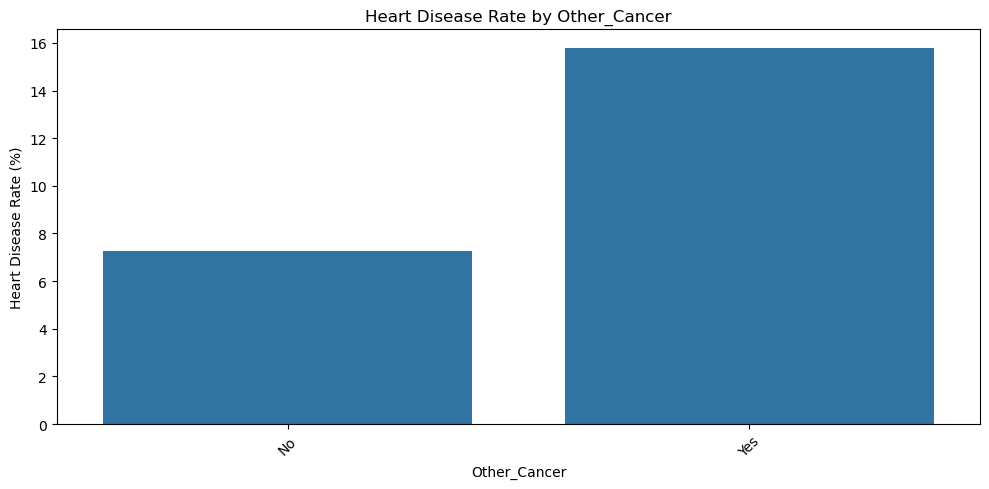

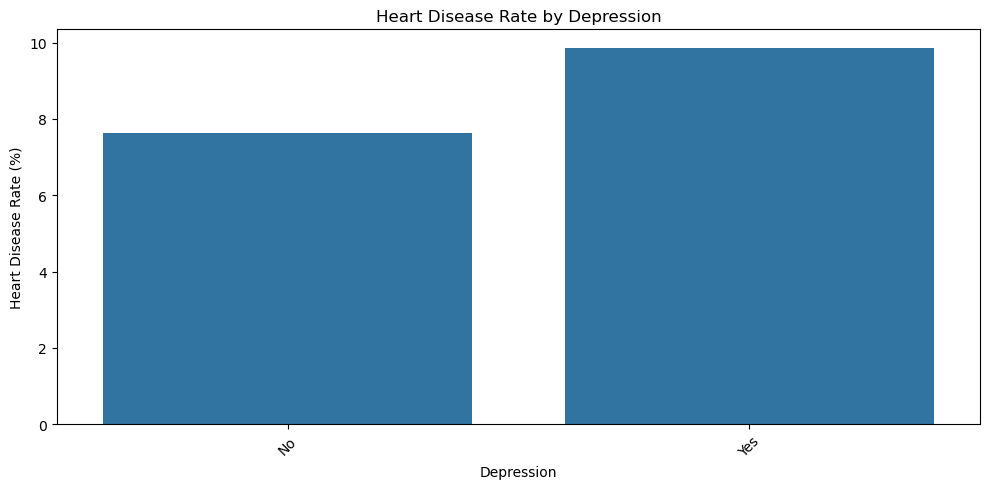

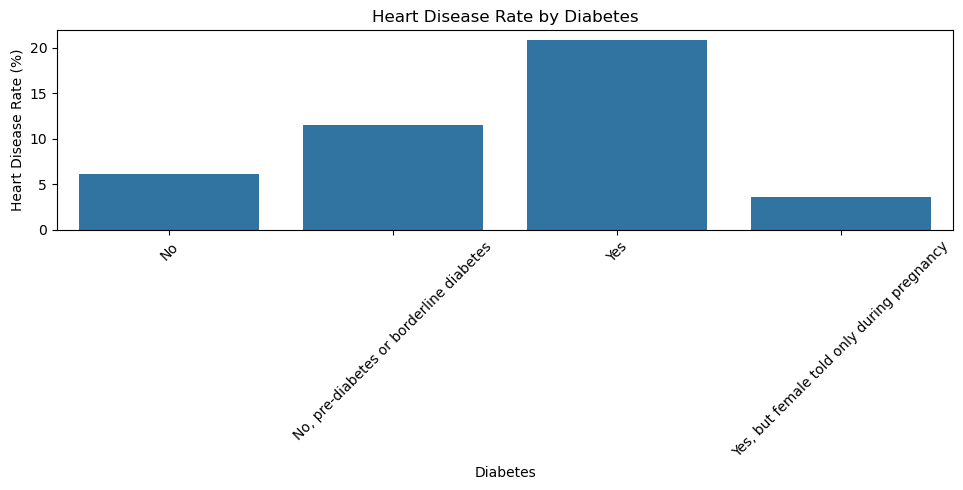

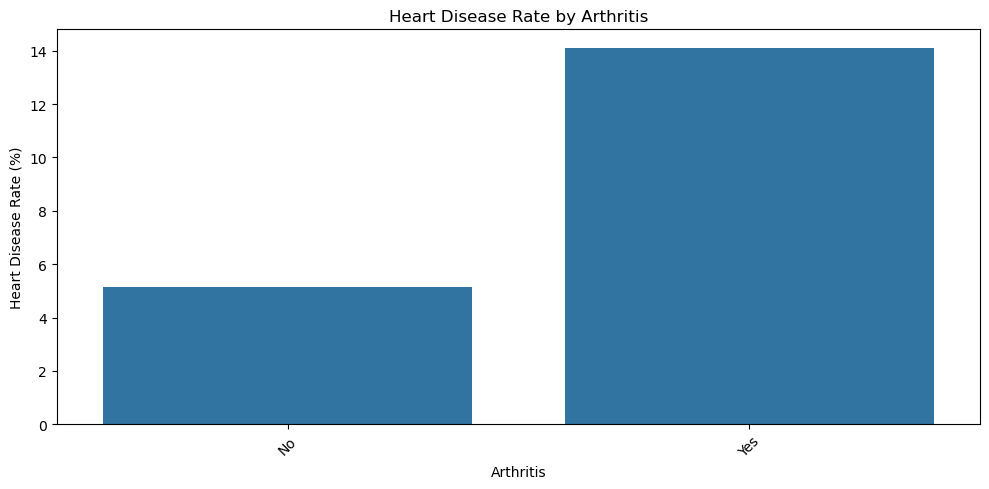

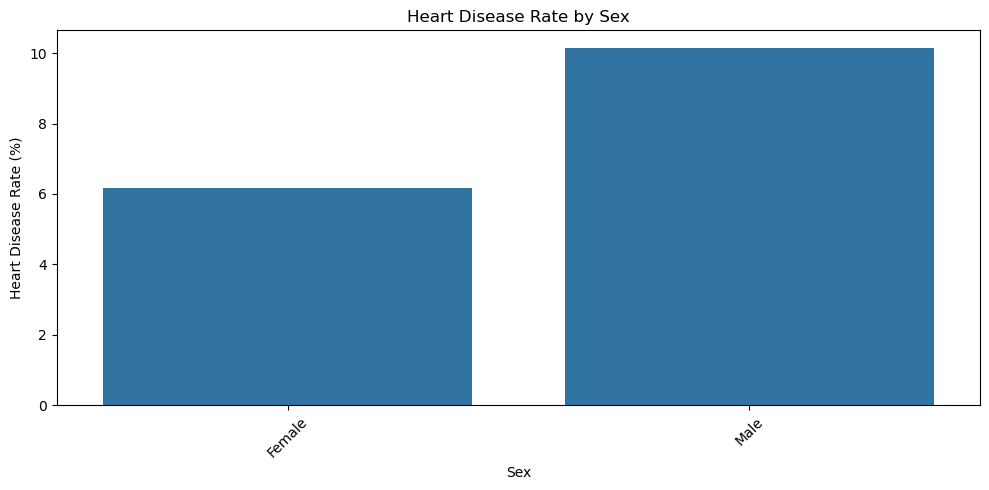

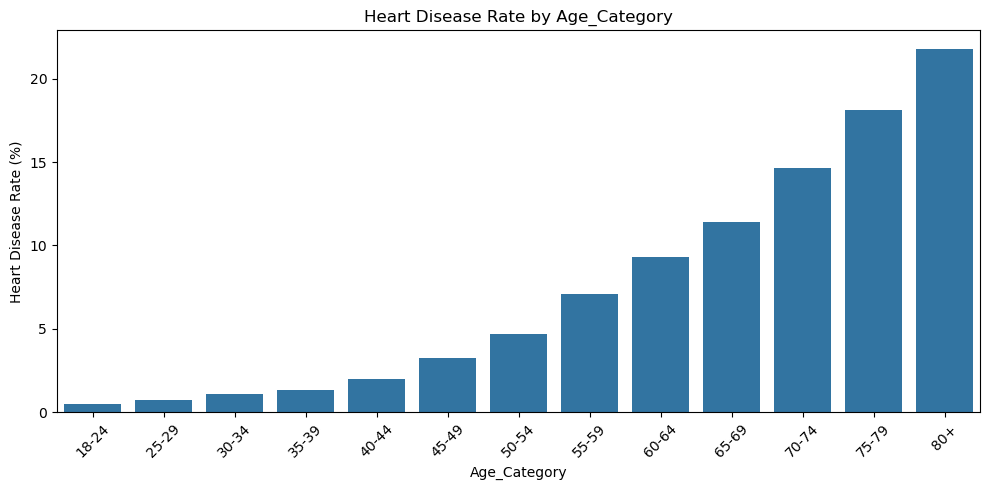

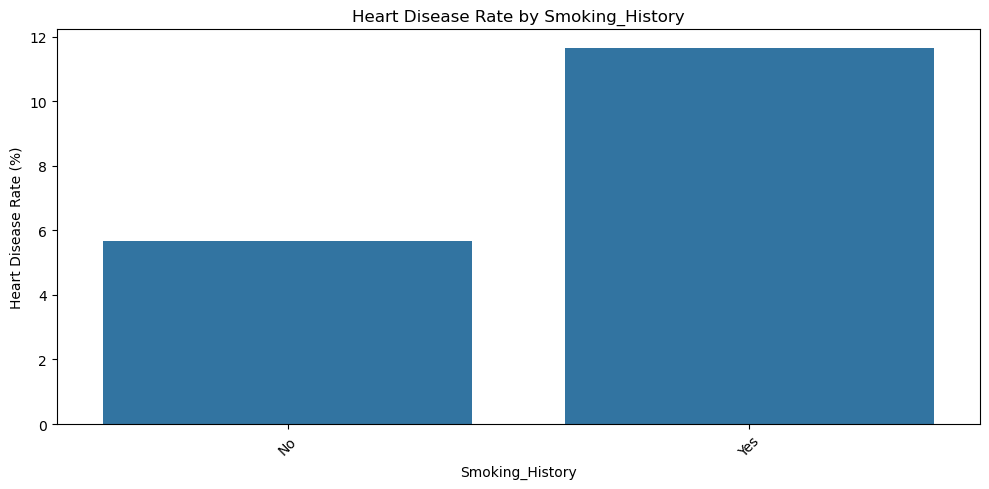

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


categorical_cols = df.select_dtypes(include=["object"]).columns.drop(
    "Heart_Disease"
)


for col in categorical_cols:

    rate = pd.crosstab(
        df[col],
        df["Heart_Disease"],
        normalize="index"
    )["Yes"] * 100

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=rate.index,
        y=rate.values
    )

    plt.title(f"Heart Disease Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Heart Disease Rate (%)")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

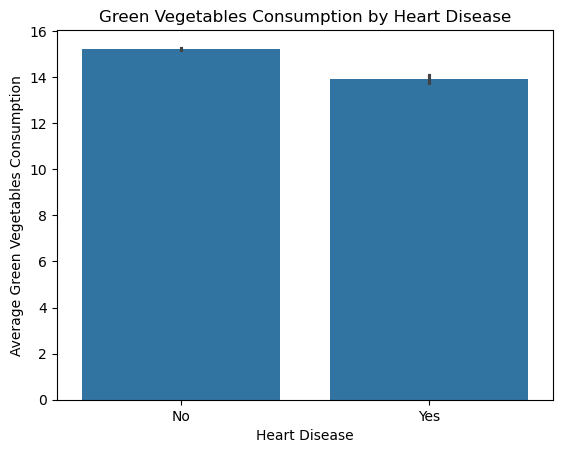

In [7]:
sns.barplot(
    data=df,
    x="Heart_Disease",
    y="Green_Vegetables_Consumption"
)

plt.title("Green Vegetables Consumption by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Average Green Vegetables Consumption")
plt.show()

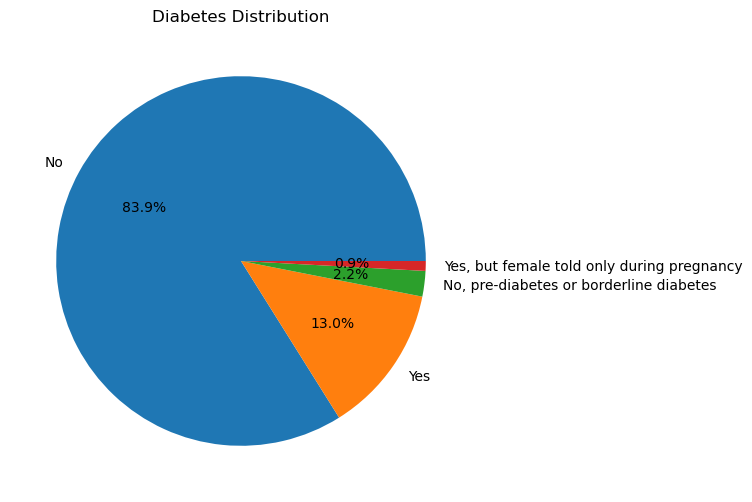

In [8]:


counts = df["Diabetes"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%"
)

plt.title("Diabetes Distribution")
plt.show()

['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Arthritis', 'Sex', 'Smoking_History']


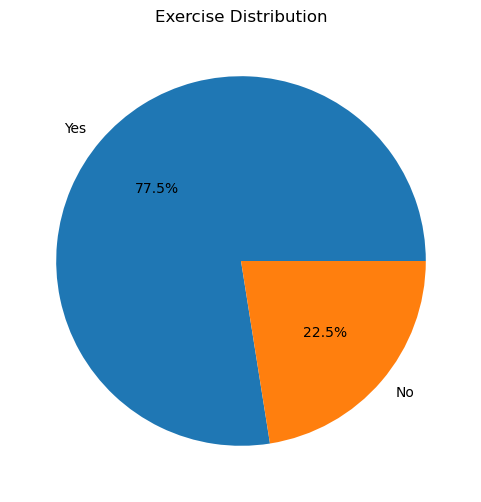

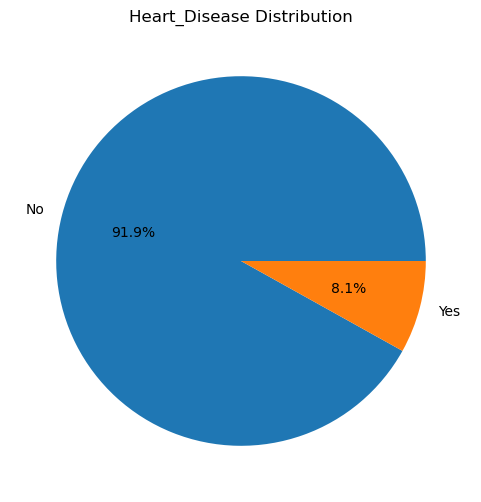

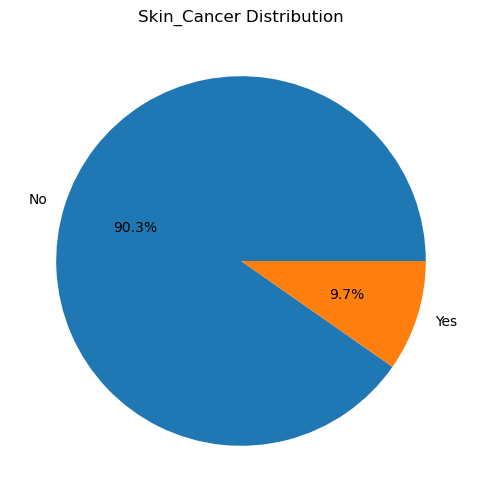

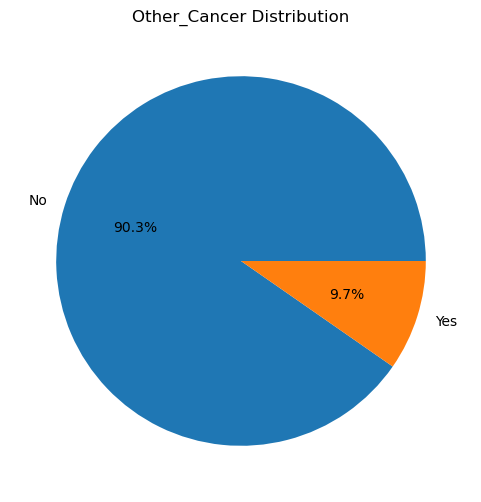

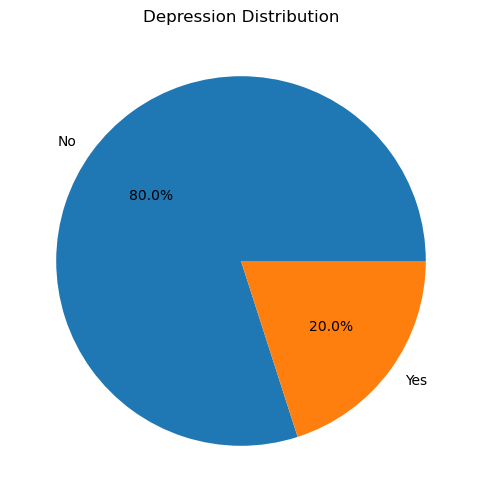

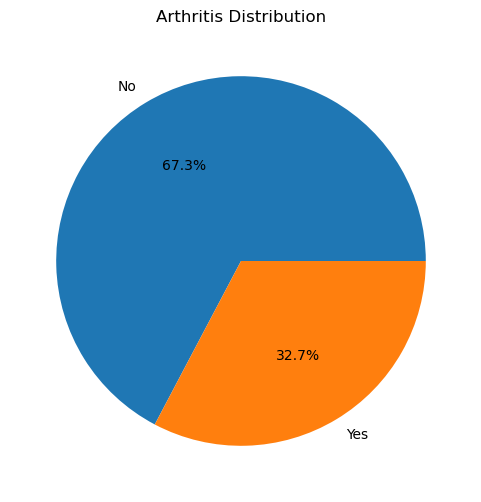

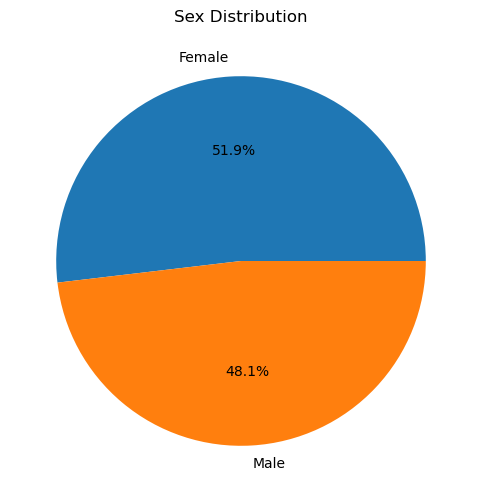

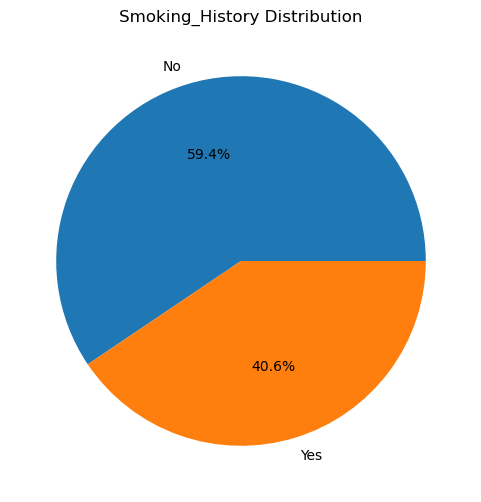

In [9]:
binary_cols = [
    col for col in df.columns
    if df[col].nunique() == 2
]

print(binary_cols)
for col in binary_cols:
    counts = df[col].value_counts()

    plt.figure(figsize=(6, 6))
    plt.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%"
    )

    plt.title(f"{col} Distribution")
    plt.show()

In [10]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


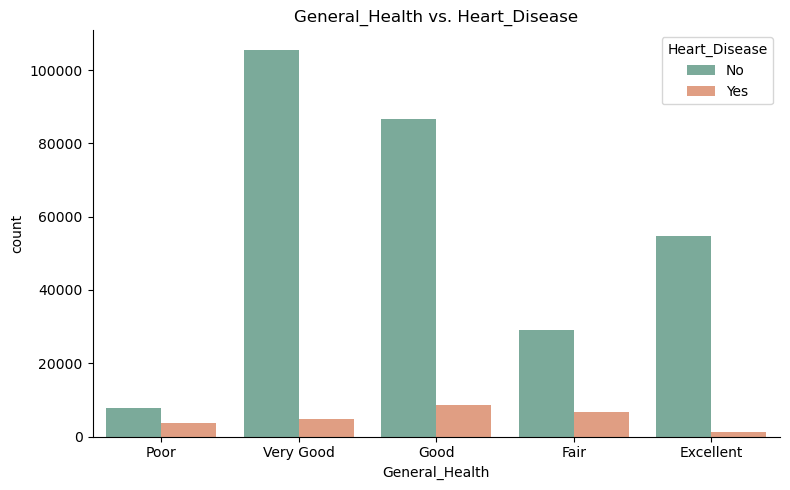

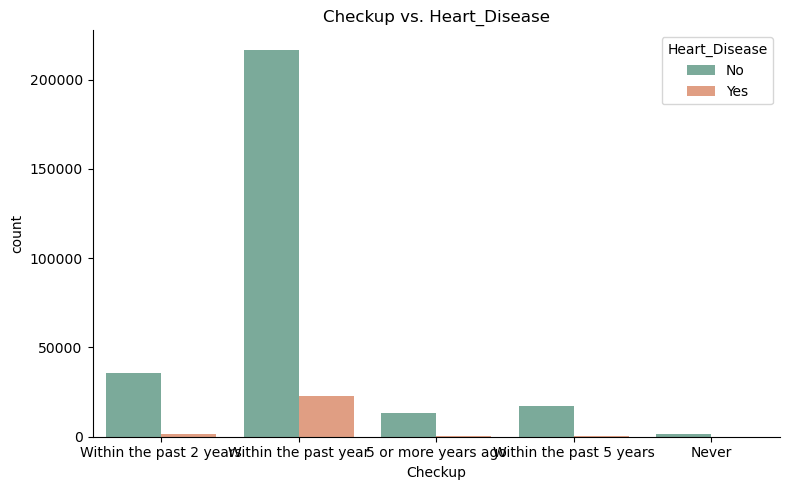

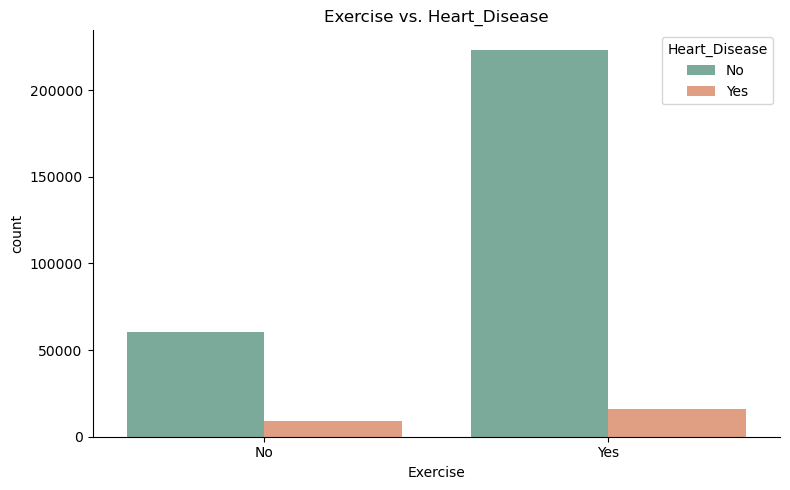

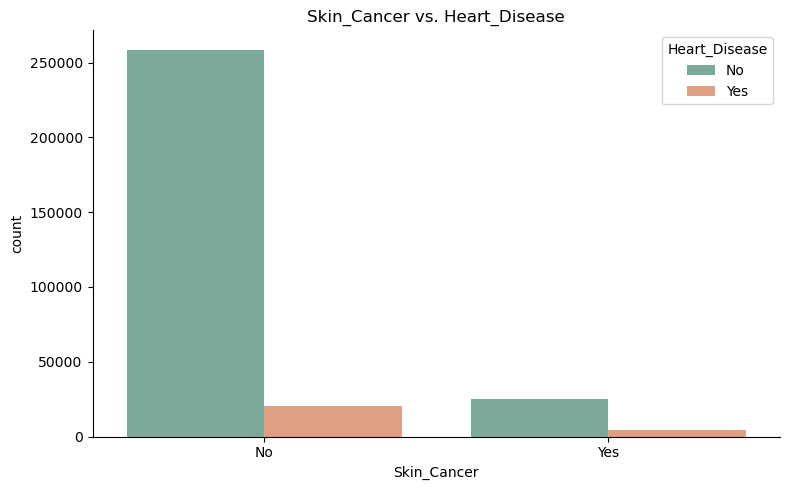

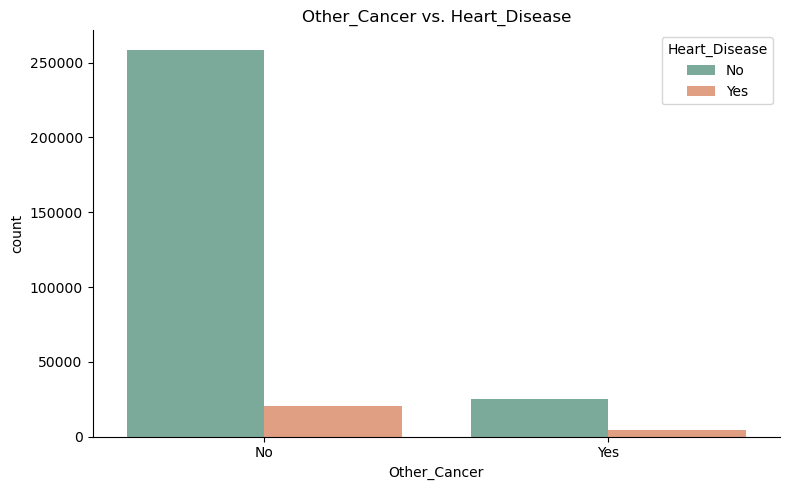

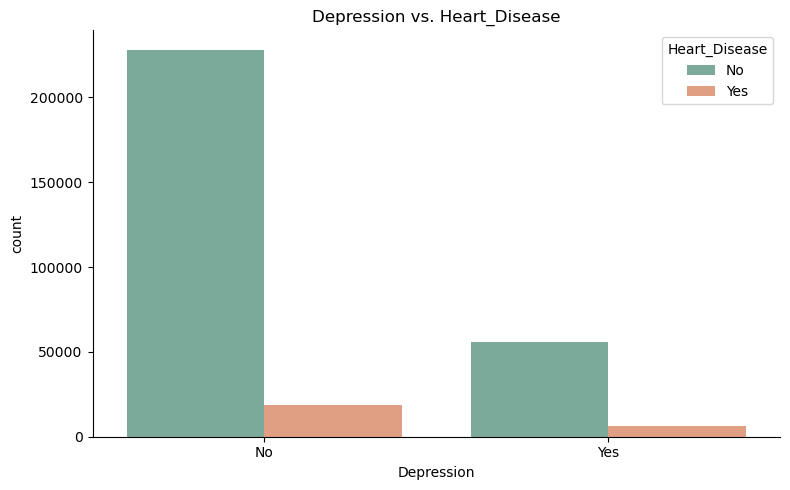

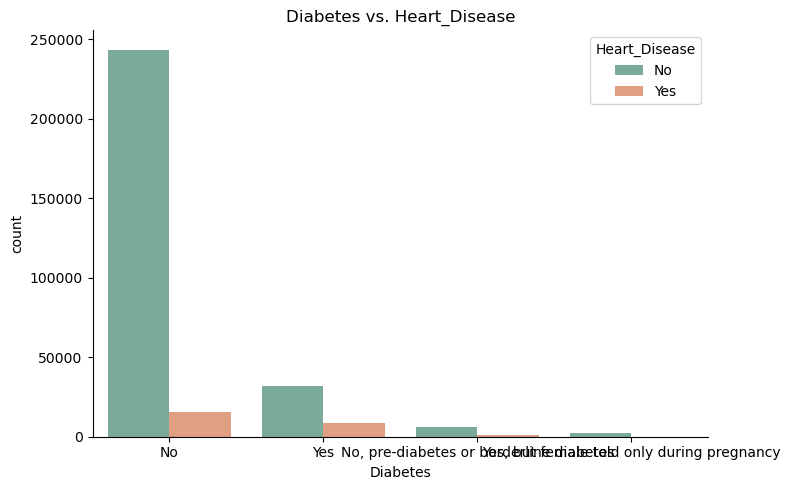

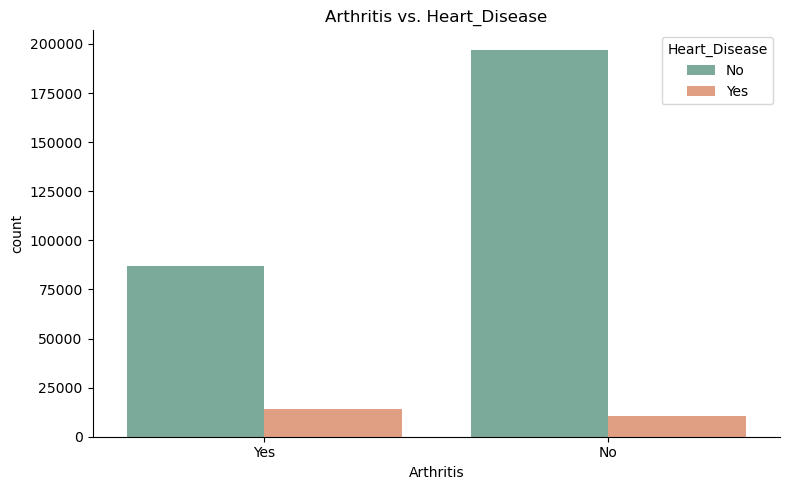

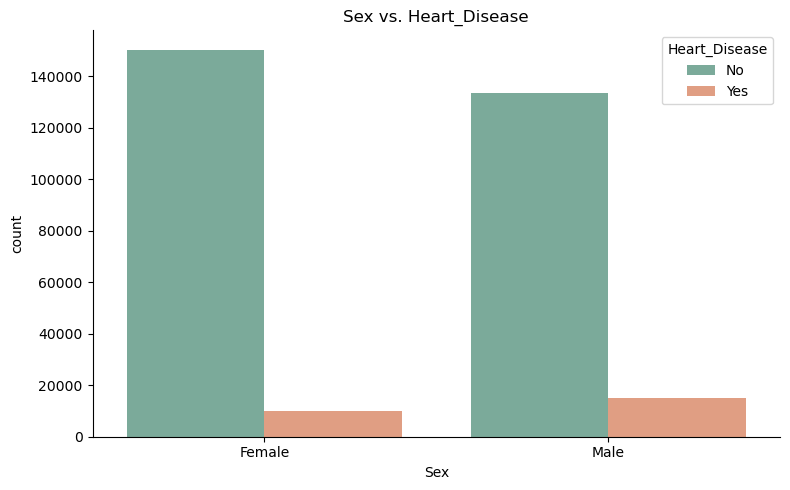

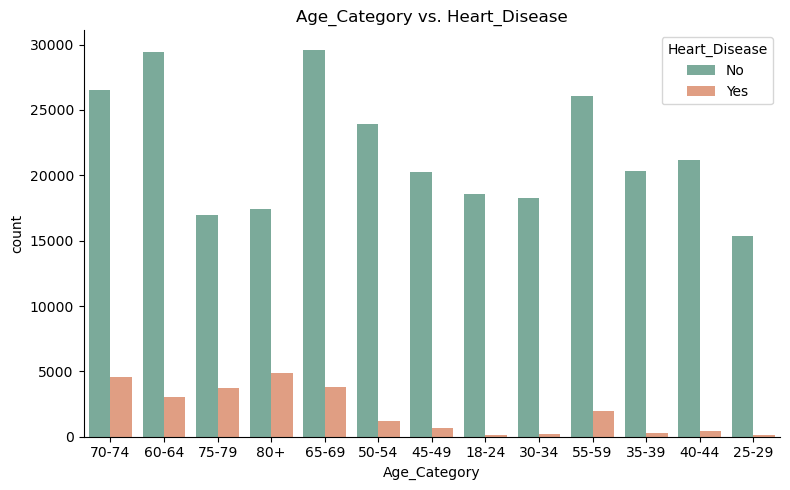

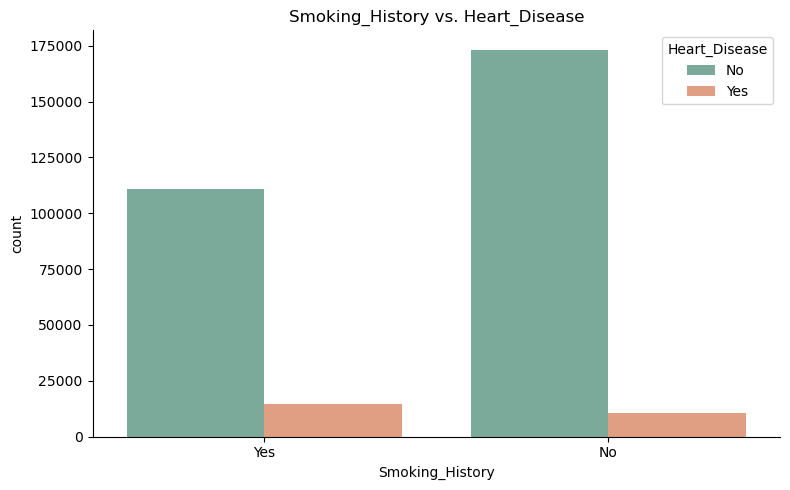

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns.drop(
    "Heart_Disease"
)

for col in categorical_cols:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue="Heart_Disease",
        palette=["#73b29c", "#f09873"],
    )

    sns.despine()
    plt.title(f"{col} vs. Heart_Disease")
    plt.tight_layout()
    plt.show()

In [12]:
df["BMI"].describe()

count    308854.000000
mean         28.626211
std           6.522323
min          12.020000
25%          24.210000
50%          27.440000
75%          31.850000
max          99.330000
Name: BMI, dtype: float64

C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\3211752881.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=bmi_rate.index, y=bmi_rate.values, palette="Reds_d")


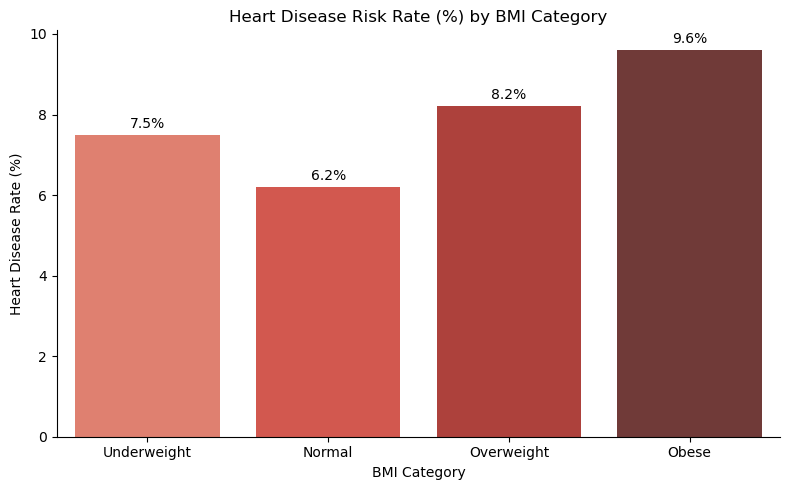

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# حساب النسبة مباشرة على Series مؤقتة بدون حفظ العمود في df
bmi_rate = (
    pd.crosstab(
        pd.cut(
            df["BMI"],
            bins=[0, 18.5, 25, 30, 100],
            labels=["Underweight", "Normal", "Overweight", "Obese"],
        ),
        df["Heart_Disease"],
        normalize="index",
    )["Yes"]
    * 100
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=bmi_rate.index, y=bmi_rate.values, palette="Reds_d")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

sns.despine()
plt.title("Heart Disease Risk Rate (%) by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Heart Disease Rate (%)")
plt.tight_layout()
plt.show()

C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\195611113.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\195611113.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\195611113.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\195611113.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to

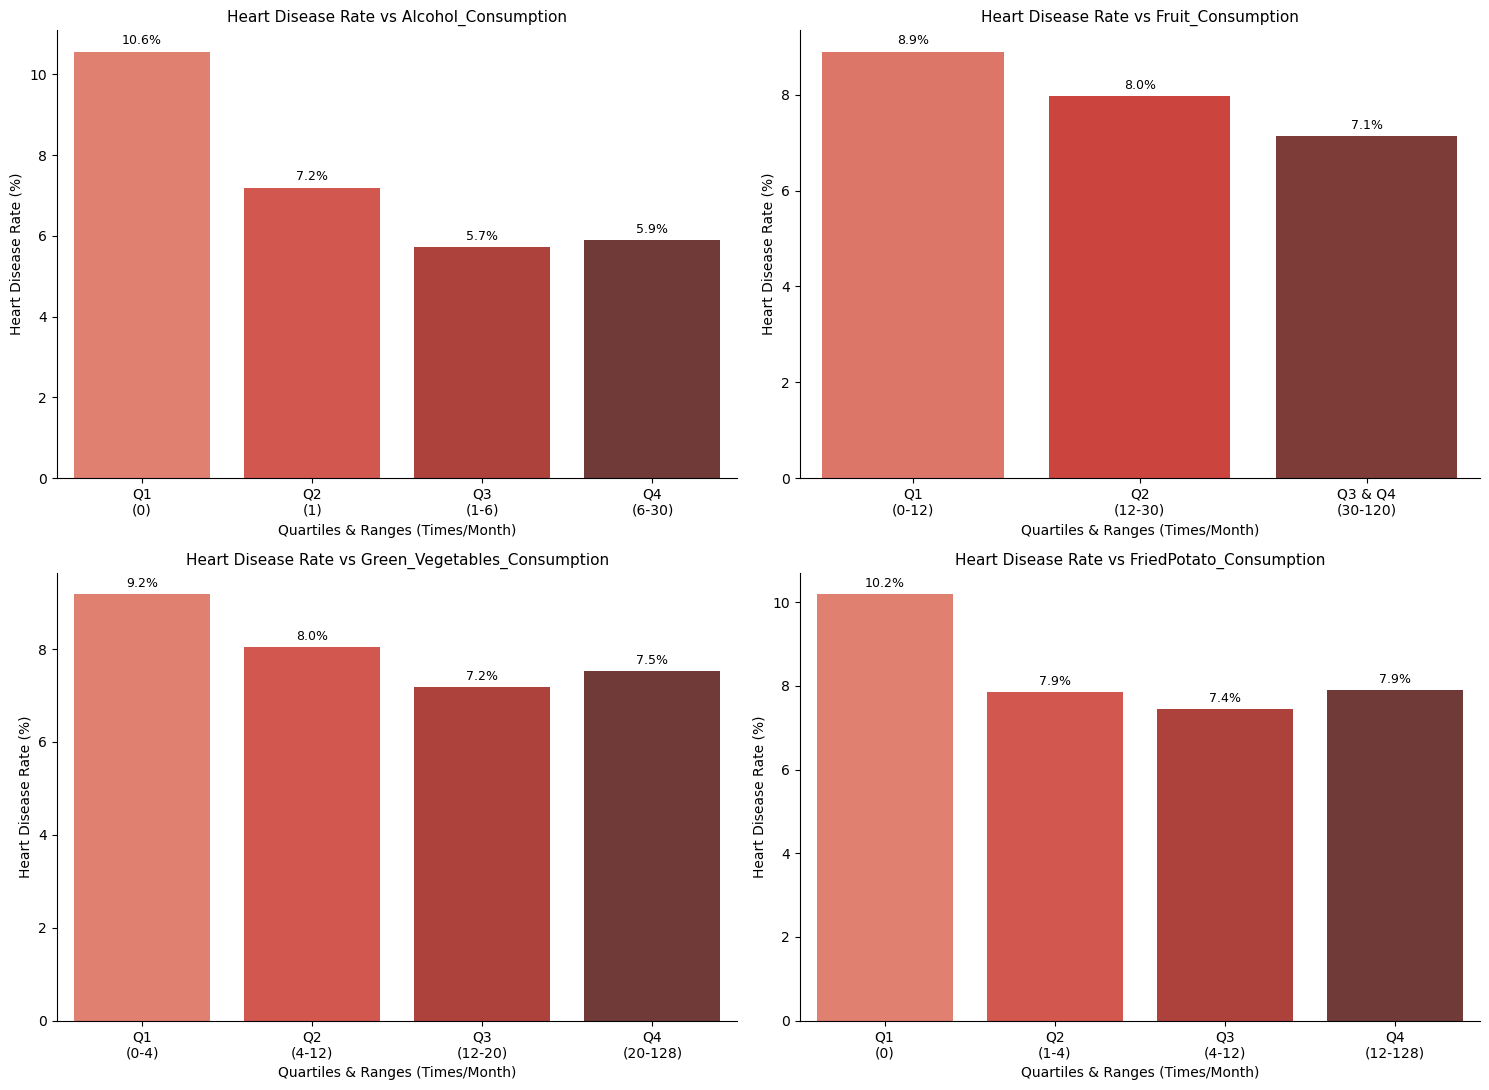

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cols = [
    "Alcohol_Consumption",
    "Fruit_Consumption",
    "Green_Vegetables_Consumption",
    "FriedPotato_Consumption",
]

bin_ranges = {
    "Alcohol_Consumption": [-1, 0, 1, 6, 30],
    "Fruit_Consumption": [-1, 12, 30, 120],
    "Green_Vegetables_Consumption": [-1, 4, 12, 20, 128],
    "FriedPotato_Consumption": [-1, 0, 4, 12, 128],
}

bin_labels = {
    "Alcohol_Consumption": ["Q1\n(0)", "Q2\n(1)", "Q3\n(1-6)", "Q4\n(6-30)"],
    "Fruit_Consumption": ["Q1\n(0-12)", "Q2\n(12-30)", "Q3 & Q4\n(30-120)"],
    "Green_Vegetables_Consumption": [
        "Q1\n(0-4)",
        "Q2\n(4-12)",
        "Q3\n(12-20)",
        "Q4\n(20-128)",
    ],
    "FriedPotato_Consumption": [
        "Q1\n(0)",
        "Q2\n(1-4)",
        "Q3\n(4-12)",
        "Q4\n(12-128)",
    ],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(cols):
    if col in bin_ranges:
        # التقسيم في متغير مؤقت بدون تعديل df
        temp_cat = pd.cut(
            df[col],
            bins=bin_ranges[col],
            labels=bin_labels[col],
            duplicates="drop",
        )

        rate = (
            pd.crosstab(temp_cat, df["Heart_Disease"], normalize="index")["Yes"]
            * 100
        )

        ax = sns.barplot(
            x=rate.index.astype(str),
            y=rate.values,
            ax=axes[i],
            palette="Reds_d",
        )

        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(
                    f"{height:.1f}%",
                    (p.get_x() + p.get_width() / 2.0, height),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords="offset points",
                )

        sns.despine(ax=axes[i])
        axes[i].set_title(f"Heart Disease Rate vs {col}", fontsize=11)
        axes[i].set_xlabel("Quartiles & Ranges (Times/Month)")
        axes[i].set_ylabel("Heart Disease Rate (%)")

plt.tight_layout()
plt.show()

In [15]:
df["FriedPotato_Consumption"].value_counts()

FriedPotato_Consumption
4     67833
0     44233
8     38366
2     36095
1     29876
      ...  
49        1
76        1
34        1
98        1
97        1
Name: count, Length: 69, dtype: int64

In [16]:
df[(df["Heart_Disease"]=="Yes")&(df["FriedPotato_Consumption"]==4.0)].count()

General_Health                  5206
Checkup                         5206
Exercise                        5206
Heart_Disease                   5206
Skin_Cancer                     5206
Other_Cancer                    5206
Depression                      5206
Diabetes                        5206
Arthritis                       5206
Sex                             5206
Age_Category                    5206
Height_(cm)                     5206
Weight_(kg)                     5206
BMI                             5206
Smoking_History                 5206
Alcohol_Consumption             5206
Fruit_Consumption               5206
Green_Vegetables_Consumption    5206
FriedPotato_Consumption         5206
dtype: int64

In [17]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


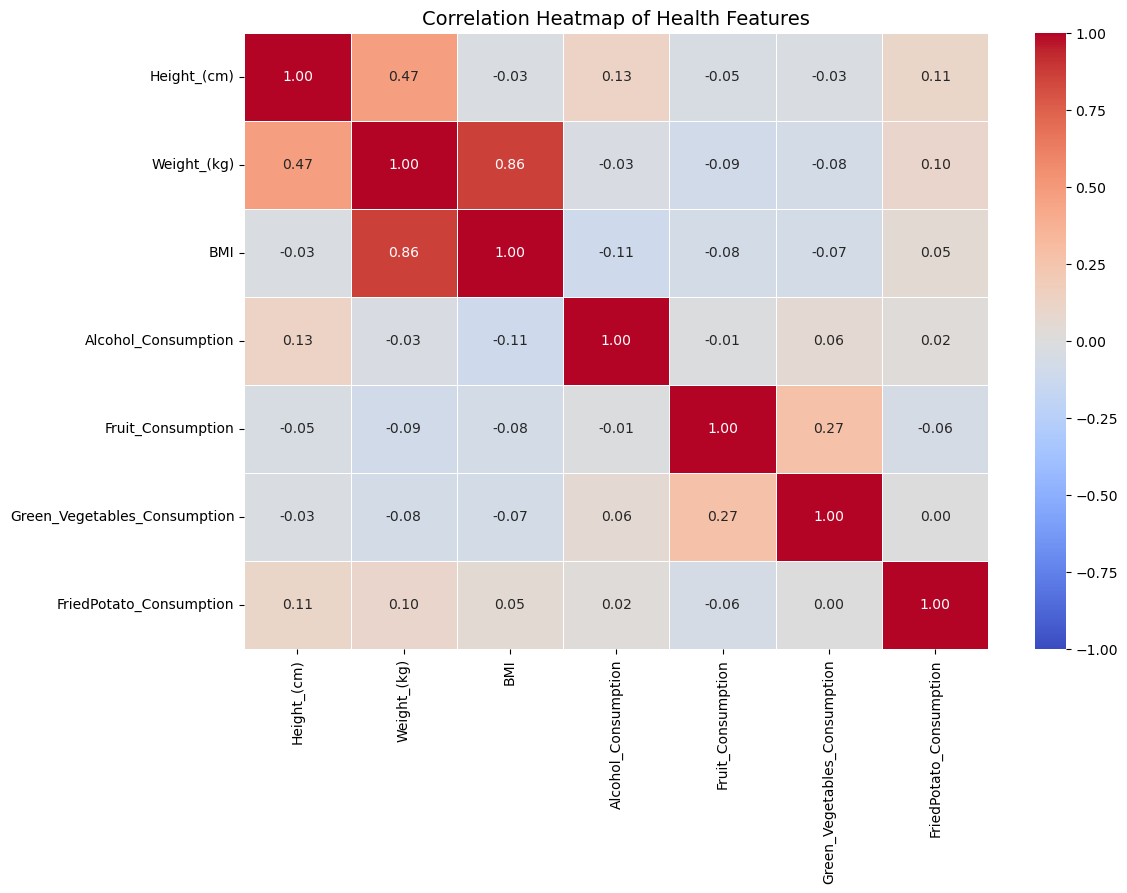

In [18]:
numeric_df = df.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  
    fmt=".2f", 
    cmap="coolwarm",  
    linewidths=0.5,  
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Heatmap of Health Features", fontsize=14)
plt.show()

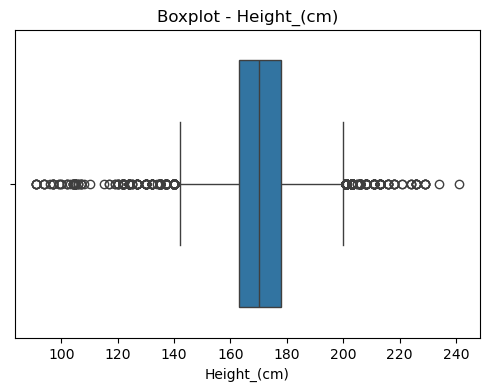

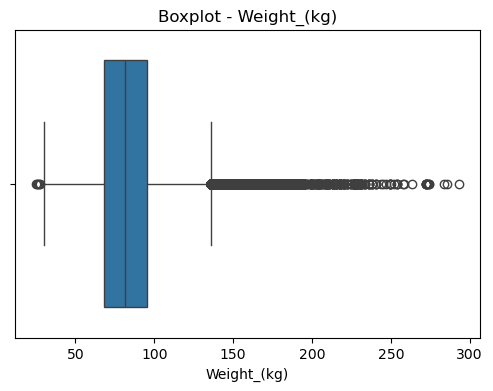

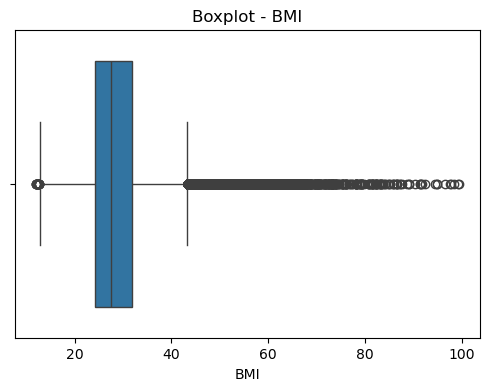

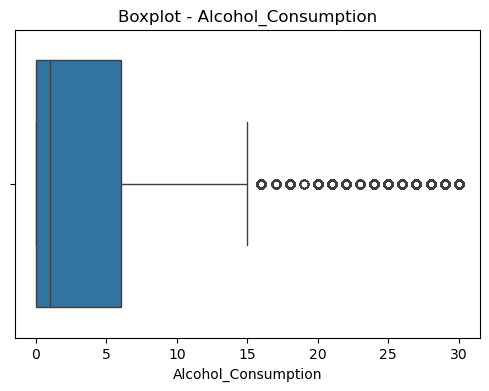

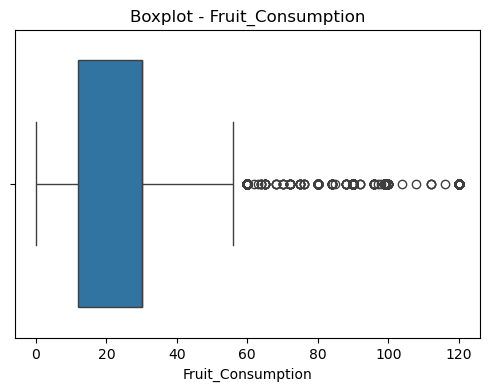

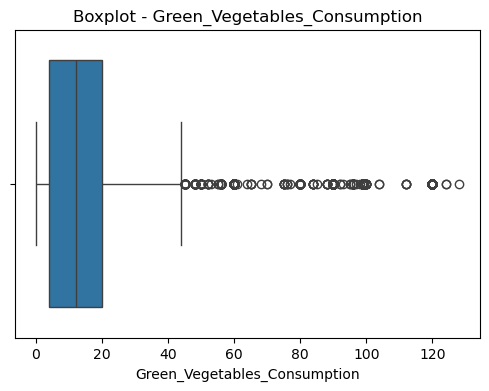

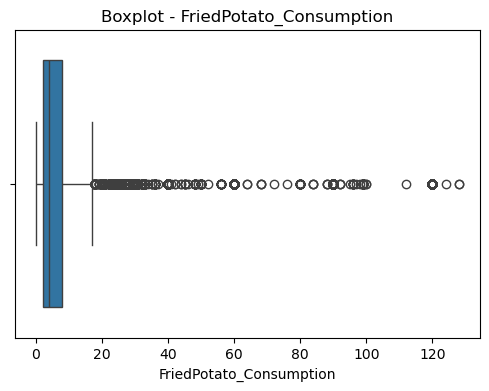

In [19]:
num_col=df.select_dtypes(include=["int64","float64"]).columns

for col in num_col:

    plt.figure(figsize=(6, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot - {col}")
    plt.show()

In [20]:
def show_outliers(df,col_outliers):
    q1=df[col_outliers].quantile(0.25)
    q3=df[col_outliers].quantile(0.75)

    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    outliers=df[(df[col_outliers]<lower)|(df[col_outliers]>upper)]
    
    print(f"\nOutliers in: {col_outliers}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Number of Outliers: {len(outliers)}")

    print("\nOutlier Values:")
    print(outliers[[col_outliers]])

    return outliers

In [21]:
Height_outlier=show_outliers(
    df,
    "Height_(cm)",
)
xx=Height_outlier[(Height_outlier["Height_(cm)"]>203)&(Height_outlier["Age_Category"]=="18-24")]
xx.sort_values(by="Height_(cm)",ascending=False)


Outliers in: Height_(cm)
Lower Bound: 140.5
Upper Bound: 200.5
Number of Outliers: 1055

Outlier Values:
        Height_(cm)
181             206
454             140
576             135
1734            201
1764            218
...             ...
307810          140
308223          135
308444          140
308560          135
308710          213

[1055 rows x 1 columns]


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
228182,Very Good,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,18-24,229,170.10,32.55,Yes,30,0,0,30
203709,Very Good,Never,No,No,No,No,No,No,No,Male,18-24,226,131.54,25.74,No,0,90,4,0
190396,Good,Within the past year,No,No,No,No,No,No,No,Male,18-24,218,68.04,14.26,No,0,0,0,0
72533,Excellent,Within the past year,Yes,No,No,No,Yes,No,No,Male,18-24,213,128.82,28.30,No,4,120,4,0
174976,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,18-24,213,81.65,17.94,Yes,8,120,8,0
299909,Good,Within the past year,Yes,No,No,No,No,No,No,Male,18-24,213,77.11,16.94,Yes,0,60,12,1
178339,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,18-24,211,97.52,21.94,No,0,20,20,8
190009,Very Good,Within the past 5 years,Yes,No,No,No,No,No,No,Male,18-24,211,77.11,17.35,Yes,4,30,4,1
210952,Fair,Within the past 2 years,No,No,Yes,No,No,Yes,No,Male,18-24,208,158.76,36.60,Yes,10,5,0,4
56743,Very Good,Within the past year,Yes,No,No,No,Yes,No,No,Male,18-24,206,127.01,30.00,No,0,30,4,4


In [22]:
Weight_outlier=show_outliers(
    df,
    "Weight_(kg)",
)
Weight_outlier[["Weight_(kg)"]].describe()


Outliers in: Weight_(kg)
Lower Bound: 27.225000000000016
Upper Bound: 136.065
Number of Outliers: 7326

Outlier Values:
        Weight_(kg)
5            154.22
29           147.42
120          136.08
273          136.08
545          158.76
...             ...
308632       143.79
308651       136.08
308660       172.37
308679       140.61
308825       136.08

[7326 rows x 1 columns]


,Weight_(kg)
count,7326.000000
mean,150.748995
std,19.256113
min,24.950000
25%,136.080000
50%,145.150000
75%,158.760000
max,293.020000


In [23]:
Weight_outlier[Weight_outlier["Weight_(kg)"]<35]

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
21368,Fair,Within the past 5 years,Yes,No,No,No,No,No,No,Female,35-39,122,25.40,17.09,No,2,24,0,3
35950,Very Good,Within the past 5 years,Yes,No,No,No,No,No,No,Female,40-44,122,26.76,18.00,No,0,30,8,4
148350,Poor,Never,Yes,No,No,Yes,No,No,No,Male,60-64,137,24.95,13.26,No,0,8,0,0
184824,Good,Within the past year,Yes,No,No,Yes,No,No,No,Female,70-74,150,27.22,12.12,Yes,0,30,8,0
216242,Fair,Within the past year,No,No,No,No,Yes,No,Yes,Female,45-49,140,26.31,13.48,No,0,3,0,0


In [24]:

df["Height_(cm)"] = df["Height_(cm)"].mask(
    (df["Height_(cm)"] < 130) | (df["Height_(cm)"] > 210)
)
df["Weight_(kg)"] = df["Weight_(kg)"].mask(df["Weight_(kg)"] < 35)

In [25]:
df=df.drop_duplicates()

In [26]:
df.isna().sum()

General_Health                    0
Checkup                           0
Exercise                          0
Heart_Disease                     0
Skin_Cancer                       0
Other_Cancer                      0
Depression                        0
Diabetes                          0
Arthritis                         0
Sex                               0
Age_Category                      0
Height_(cm)                     237
Weight_(kg)                      48
BMI                               0
Smoking_History                   0
Alcohol_Consumption               0
Fruit_Consumption                 0
Green_Vegetables_Consumption      0
FriedPotato_Consumption           0
dtype: int64

In [27]:
df.dtypes

General_Health                   object
Checkup                          object
Exercise                         object
Heart_Disease                    object
Skin_Cancer                      object
Other_Cancer                     object
Depression                       object
Diabetes                         object
Arthritis                        object
Sex                              object
Age_Category                     object
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                  object
Alcohol_Consumption               int64
Fruit_Consumption                 int64
Green_Vegetables_Consumption      int64
FriedPotato_Consumption           int64
dtype: object

In [28]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

df[binary_cols] = df[binary_cols].astype("category")

print("category:")
print(binary_cols)

category:
['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Arthritis', 'Sex', 'Smoking_History']


C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\898094179.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[binary_cols] = df[binary_cols].astype("category")


In [29]:
df.dtypes

General_Health                    object
Checkup                           object
Exercise                        category
Heart_Disease                   category
Skin_Cancer                     category
Other_Cancer                    category
Depression                      category
Diabetes                          object
Arthritis                       category
Sex                             category
Age_Category                      object
Height_(cm)                      float64
Weight_(kg)                      float64
BMI                              float64
Smoking_History                 category
Alcohol_Consumption                int64
Fruit_Consumption                  int64
Green_Vegetables_Consumption       int64
FriedPotato_Consumption            int64
dtype: object

In [30]:
df["Healthy_Diet_Index"] = (
    df["Fruit_Consumption"] + df["Green_Vegetables_Consumption"]
)
df["Unhealthy_Diet_Index"] = df["FriedPotato_Consumption"]
df

C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\491623794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Healthy_Diet_Index"] = (
C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\491623794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Unhealthy_Diet_Index"] = df["FriedPotato_Consumption"]


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Healthy_Diet_Index,Unhealthy_Diet_Index
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,...,150.0,NaN,14.54,Yes,0,30,16,12,46,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,...,165.0,77.11,28.29,No,0,30,0,4,30,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,...,163.0,88.45,33.47,No,4,12,3,16,15,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,...,180.0,93.44,28.73,No,0,30,30,8,60,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,...,191.0,88.45,24.37,Yes,0,8,4,0,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,...,168.0,81.65,29.05,No,4,30,8,0,38,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,...,180.0,69.85,21.48,No,8,15,60,4,75,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,...,157.0,61.23,24.69,Yes,4,40,8,4,48,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,...,183.0,79.38,23.73,No,3,30,12,0,42,0


In [31]:
df["Heart_Disease"]=df["Heart_Disease"].replace({"Yes":1,"No":0})

C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\2687150040.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Heart_Disease"]=df["Heart_Disease"].replace({"Yes":1,"No":0})
C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\2687150040.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Heart_Disease"]=df["Heart_Disease"].replace({"Yes":1,"No":0})
C:\Users\mosa\AppData\Local\Temp\ipykernel_3088\2687150040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [32]:
x = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True,stratify=y)

print(f"Shape Train : {x_train.shape}")
print(f"Shape Test : {x_test.shape}")

Shape Train : (247019, 20)
Shape Test : (61755, 20)


In [33]:
# تحديد الأعمدة الرقمية تلقائيًا
numerical_col = x_train.select_dtypes(
    include=["float64", "int64", "float32", "int32"]
).columns.tolist()


# الأعمدة التي نريد تطبيق Log Transform عليها
log_cols = [
    "Alcohol_Consumption",
    "Green_Vegetables_Consumption",
    "FriedPotato_Consumption"
]

# الاحتفاظ فقط بالأعمدة الموجودة فعلًا في x_train
log_cols = [
    col for col in log_cols
    if col in numerical_col
]


# باقي الأعمدة الرقمية بدون Log Transform
normal_numeric_cols = [
    col for col in numerical_col
    if col not in log_cols
]


# الأعمدة النصية أو categorical
all_categorical_cols = x_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# الأعمدة المرتبة
ordinal_col = [
    col for col in all_categorical_cols
    if col in ["Checkup", "General_Health"]
]


# باقي الأعمدة categorical
categorical_col = [
    col for col in all_categorical_cols
    if col not in ordinal_col
]


print("Normal Numeric Columns:")
print(normal_numeric_cols)

print("\nLog Numeric Columns:")
print(log_cols)

print("\nAll Numerical Columns:")
print(numerical_col)

print("\nOrdinal Columns:")
print(ordinal_col)

print("\nCategorical Columns:")
print(categorical_col)


Normal Numeric Columns:
['Height_(cm)', 'Weight_(kg)', 'BMI', 'Fruit_Consumption', 'Healthy_Diet_Index', 'Unhealthy_Diet_Index']

Log Numeric Columns:
['Alcohol_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

All Numerical Columns:
['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'Healthy_Diet_Index', 'Unhealthy_Diet_Index']

Ordinal Columns:
['General_Health', 'Checkup']

Categorical Columns:
['Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']


In [34]:
normal_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", CustomNumericalImputer(stratigy="median")),
        ("scaler", RobustScaler())
    ]
)

log_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", CustomNumericalImputer(stratigy="median")),
        ("log_transform", FunctionTransformer(np.log1p)),
        ("scaler", RobustScaler())
    ]
)

health_order = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
checkup_order = [
    "Never",
    "5 or more years ago",
    "Within the past 5 years",
    "Within the past 2 years",
    "Within the past year",
]

ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[health_order,checkup_order],handle_unknown="use_encoded_value", unknown_value=-1
            ),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore", drop="first", sparse_output=False
            ),
        ),
    ]
)

process = ColumnTransformer(
    transformers=[
        ("normal_num", normal_numeric_pipeline, normal_numeric_cols),
        ("log_num", log_numeric_pipeline, log_cols),
        ("ord", ordinal_pipeline, ordinal_col),
        ("cat", categorical_pipeline, categorical_col)
    ],
    remainder="drop"
)


In [35]:
def evaluation_test(model, name, x_test, y_test):
    y_pred_test = model.predict(x_test)
    AUC= model.predict_proba(x_test)[:, 1]
    


    score = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred_test),
        "Precision": precision_score(
            y_test,
            y_pred_test,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_test,
            pos_label=1,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_test,
            pos_label=1,
            zero_division=0
        ),
        "AUC":roc_auc_score(
            y_test,
            AUC
        )
    }

    return score, y_pred_test

In [36]:
logistic_pipeline = Pipeline([
    ("preprocessor", process),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_pipeline.fit(x_train, y_train)

log_score, log_pred = evaluation_test(
    logistic_pipeline,
    "Logistic Regression",
    x_test,
    y_test
)

print(log_score)

print(classification_report(y_test,log_pred))

{'model': 'Logistic Regression', 'accuracy': 0.7362804631203951, 'Precision': 0.20770345827293435, 'Recall': 0.8033640368442131, 'F1': 0.3300699300699301, 'AUC': 0.8389936813025369}
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     56761
           1       0.21      0.80      0.33      4994

    accuracy                           0.74     61755
   macro avg       0.59      0.77      0.58     61755
weighted avg       0.91      0.74      0.79     61755



In [37]:
xgb_pipeline = Pipeline([
    ("preprocessor", process),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            
        )
    )
])

xgb_pipeline.fit(x_train, y_train)

xgb_score, xgb_pred = evaluation_test(
    xgb_pipeline,
    "XGBoost",
    x_test,
    y_test
)

print(xgb_score)
print(classification_report(y_test,xgb_pred))

{'model': 'XGBoost', 'accuracy': 0.9194721075216582, 'Precision': 0.5286103542234333, 'Recall': 0.03884661593912695, 'F1': 0.07237455698563701, 'AUC': 0.8387606114987955}
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56761
           1       0.53      0.04      0.07      4994

    accuracy                           0.92     61755
   macro avg       0.73      0.52      0.52     61755
weighted avg       0.89      0.92      0.89     61755



In [38]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", process),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_pipeline.fit(x_train, y_train)

rf_score, rf_pred = evaluation_test(
    random_forest_pipeline,
    "Random Forest",
    x_test,
    y_test
)

print(rf_score)
print(classification_report(y_test,rf_pred))

{'model': 'Random Forest', 'accuracy': 0.7599060804793134, 'Precision': 0.21791267427850136, 'Recall': 0.7605126151381658, 'F1': 0.33875930963742584, 'AUC': 0.8338909000485049}
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     56761
           1       0.22      0.76      0.34      4994

    accuracy                           0.76     61755
   macro avg       0.60      0.76      0.60     61755
weighted avg       0.91      0.76      0.81     61755



In [39]:
all_scores = pd.DataFrame([
    log_score,
    xgb_score,
    rf_score
])

all_scores = all_scores.sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

all_scores

,model,accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.736280,0.207703,0.803364,0.330070,0.838994
1,XGBoost,0.919472,0.528610,0.038847,0.072375,0.838761
2,Random Forest,0.759906,0.217913,0.760513,0.338759,0.833891


In [40]:
logistic_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": ["balanced", None]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

logistic_grid.fit(x_train, y_train)

print("Best Parameters:")
print(logistic_grid.best_params_)

print("Best CV F1:")
print(logistic_grid.best_score_)

log_grid_score, log_grid_pred = evaluation_test(
    logistic_grid.best_estimator_,
    "Logistic Regression GridSearch",
    x_test,
    y_test
)

print(log_grid_score)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}
Best CV F1:
0.32611628111224616
{'model': 'Logistic Regression GridSearch', 'accuracy': 0.7402315601975549, 'Precision': 0.20975199663724253, 'Recall': 0.7993592310772928, 'F1': 0.33230666777657536, 'AUC': 0.8383311043529361}


In [41]:
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__scale_pos_weight": [1, 5]
}
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(x_train, y_train)

print("Best Parameters:")
print(xgb_grid.best_params_)

print("Best CV F1:")
print(xgb_grid.best_score_)

xgb_grid_score, xgb_grid_pred = evaluation_test(
    xgb_grid.best_estimator_,
    "XGBoost GridSearch",
    x_test,
    y_test
)

print(xgb_grid_score)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__scale_pos_weight': 5, 'model__subsample': 0.8}
Best CV F1:
0.36909155543701916
{'model': 'XGBoost GridSearch', 'accuracy': 0.8511051736701482, 'Precision': 0.2852908105897986, 'Recall': 0.5588706447737285, 'F1': 0.3777492048453678, 'AUC': 0.8388297118784223}


In [42]:
rf_param_grid = {

    "model__n_estimators": [200, 300],

    "model__max_depth": [8, 12, None],

    "model__min_samples_split": [2, 5],

    "model__min_samples_leaf": [1, 2],

    "model__max_features": ["sqrt"]
}


rf_grid = GridSearchCV(

    estimator=random_forest_pipeline,

    param_grid=rf_param_grid,

    scoring="f1",

    cv=3,

    n_jobs=-1,

    verbose=2
)


rf_grid.fit(x_train, y_train)


print("Best Parameters:")
print(rf_grid.best_params_)

print("Best CV F1:")
print(rf_grid.best_score_)


rf_grid_score, rf_grid_pred = evaluation_test(

    rf_grid.best_estimator_,

    "Random Forest GridSearch",

    x_test,

    y_test
)

print(rf_grid_score)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV F1:
0.33585688938852204
{'model': 'Random Forest GridSearch', 'accuracy': 0.7640514938061695, 'Precision': 0.21998713525524824, 'Recall': 0.7533039647577092, 'F1': 0.3405295315682281, 'AUC': 0.8325650758712115}


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

for name, model in models.items():
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_prob = model.predict_proba(x_train)[:, 1]
    test_prob = model.predict_proba(x_test)[:, 1]

    print("\n", name)

    print("Train F1:",
          f1_score(y_train, train_pred, zero_division=0))

    print("Test F1:",
          f1_score(y_test, test_pred, zero_division=0))

    print("Train Recall:",
          recall_score(y_train, train_pred, zero_division=0))

    print("Test Recall:",
          recall_score(y_test, test_pred, zero_division=0))

    print("Train Precision:",
          precision_score(y_train, train_pred, zero_division=0))

    print("Test Precision:",
          precision_score(y_test, test_pred, zero_division=0))

    print("Train AUC:",
          roc_auc_score(y_train, train_prob))

    print("Test AUC:",
          roc_auc_score(y_test, test_prob))



 Logistic Regression
Train F1: 0.3257959930168759
Test F1: 0.33230666777657536
Train Recall: 0.7847024077689343
Test Recall: 0.7993592310772928
Train Precision: 0.20557340502262147
Test Precision: 0.20975199663724253
Train AUC: 0.8336953029673927
Test AUC: 0.8383311043529361

 XGBoost
Train F1: 0.3749557596696722
Test F1: 0.3777492048453678
Train Recall: 0.5568403664213846
Test Recall: 0.5588706447737285
Train Precision: 0.2826363128207734
Test Precision: 0.2852908105897986
Train AUC: 0.8382566596215275
Test AUC: 0.8388297118784223

 Random Forest
Train F1: 0.3680420308890801
Test F1: 0.3405295315682281
Train Recall: 0.8135355659007859
Test Recall: 0.7533039647577092
Train Precision: 0.23781442514523185
Test Precision: 0.21998713525524824
Train AUC: 0.8702184134361787
Test AUC: 0.8325650758712115


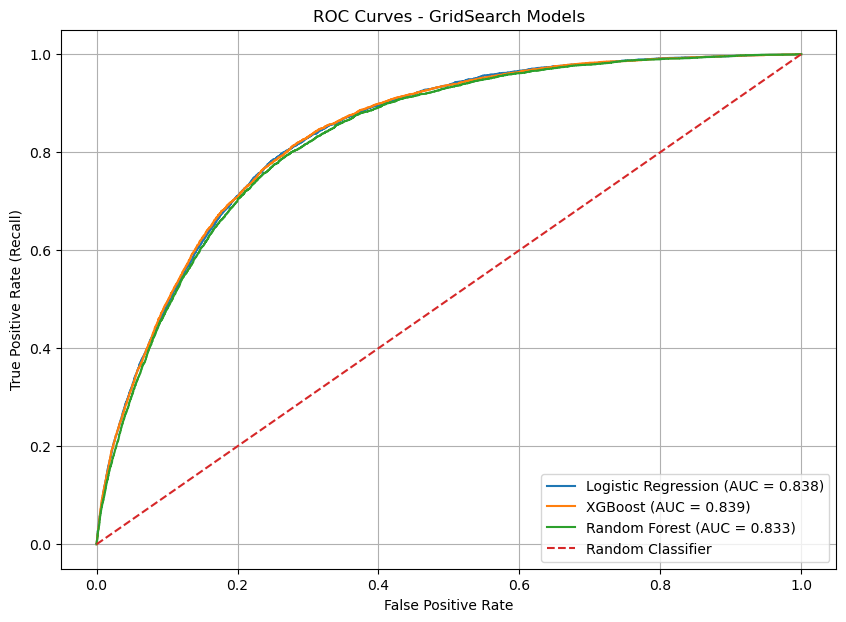

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

logistic_prob = logistic_grid.best_estimator_.predict_proba(x_test)[:, 1]
xgb_prob = xgb_grid.best_estimator_.predict_proba(x_test)[:, 1]
rf_prob = rf_grid.best_estimator_.predict_proba(x_test)[:, 1]

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)


logistic_auc = auc(logistic_fpr, logistic_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves - GridSearch Models")
plt.legend()
plt.grid()

plt.show()

In [45]:
import joblib

models_data = {
    "Logistic Regression": {
        "model": logistic_grid.best_estimator_,
        "metrics": log_grid_score,
        "description": "Good for detecting class 1 cases and easy to interpret"
    },
    "XGBoost": {
        "model": xgb_grid.best_estimator_,
        "metrics": xgb_grid_score,
        "description": "Good for strong overall performance and complex relationships"
    },
    "Random Forest": {
        "model": rf_grid.best_estimator_,
        "metrics": rf_grid_score,
        "description": "Good for stable predictions with many features"
    }
}

joblib.dump(models_data, "heart_disease_models.pkl")
print("Models saved successfully")


Models saved successfully
